In [7]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx,to_dense_adj
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [8]:
#Lecture avec NetworkX
G = nx.read_graphml("airportsAndCoordAndPop.graphml")

# On met toutes les caractéristiques dans un DF
data_list = []
for node_id, attrs in G.nodes(data=True):
    data_list.append({
        "id": node_id,
        "city_name": attrs.get("city_name"),
        "country": attrs.get("country"),
        "lat": float(attrs.get("lat", 0.0)),
        "lon": float(attrs.get("lon", 0.0)),
        "population": int(attrs.get("population", 0)),
    })

df = pd.DataFrame(data_list)
df["nb_liaisons"] = df["id"].map(dict(G.degree()))
#Aperçu rapide
print("\n Aperçu des données(10ere lignes)")
print(df.head(10))
#Liaisons => arêtes Noeuds => aéroports


 Aperçu des données(10ere lignes)
  id       city_name           country        lat         lon  population  \
0  0            Anaa  FRENCH_POLYNESIA -17.353889 -145.509722       10000   
1  1      Hao Island  FRENCH_POLYNESIA -18.066667 -140.950000       10000   
2  2         Papeete  FRENCH_POLYNESIA -17.550000 -149.600000       26357   
3  3  Gambier Island  FRENCH_POLYNESIA -23.033333 -135.000000       10000   
4  4          Makemo  FRENCH_POLYNESIA -16.584889 -143.657250       10000   
5  5        Auckland       NEW_ZEALAND -37.008056  174.791667      417910   
6  6          Atuona  FRENCH_POLYNESIA  -9.800000 -139.033333       10000   
7  7       Bora Bora  FRENCH_POLYNESIA -16.450000 -151.750000       10000   
8  8        Honolulu               USA  21.318691 -157.922407      371657   
9  9         Huahine  FRENCH_POLYNESIA -16.680000 -151.000000       10000   

   nb_liaisons  
0            2  
1            4  
2           27  
3            2  
4            2  
5           44 

In [9]:
# Beaucoup de ville avec population = 10000 => anomalie ?
# S'assurer que les identifiants de nœuds sont bien des entiers contigus 0..N-1
G = nx.convert_node_labels_to_integers(G)

print(f"Nombre d'aéroports : {G.number_of_nodes()}")
print(f"Nombre de liaisons  : {G.number_of_edges()}")

# nom des villes et pays
cities = [G.nodes[i].get("city_name", f"Airport_{i}") for i in range(len(G))]
countries = [G.nodes[i].get("country", "Unknown") for i in range(len(G))]

# 3. Extraction des attributs d'entrée X (lat, lon) 
lat = np.array([float(G.nodes[i]["lat"]) for i in range(len(G))])
lon = np.array([float(G.nodes[i]["lon"]) for i in range(len(G))])
pop = np.array([float(G.nodes[i]["population"]) for i in range(len(G))])

# conversion pour pytorch
data = from_networkx(G)



Nombre d'aéroports : 3363
Nombre de liaisons  : 13547


In [10]:
# Normalisation des caractéristiques numériques
#scaler = StandardScaler()
#features_scaled = scaler.fit_transform(np.stack([lat, lon, pop], axis=1))

# Assignation à data.x
#data.x = th.tensor(features_scaled, dtype=th.float)

pop_matrix = pop.reshape(-1, 1)
#Parce qu'on a un trop grand écart au sein des populations 
pop_log = np.log1p(pop_matrix)
# Normalisation de la population uniquement
scaler = StandardScaler()
features_scaled = scaler.fit_transform(pop_matrix)

data.x = th.tensor(features_scaled, dtype=th.float)

In [11]:
#Démarche : DOMINANT du papier de la slide 53 du cours 
# En gros un encodeur GCN classique qui prend A la structure et X les attributs
# pour produire des embeddings pour chaque noeud
# Un décodeur qui prend les embeddings et essaie de reconstruire la structure Â
# Un décodeur pour les attributs qui donnera ^x
# Avec des fonctions données Ldominant pour minimiser l'erreur et score(i) pour classer à la fin

In [12]:

class DOMINANT(nn.Module):
    def __init__(self, num_features, hidden_dim, embedding_dim):
        super(DOMINANT, self).__init__()
        
        # encodeur GCN
        self.gcn1 = GCNConv(num_features, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, embedding_dim)
        
        # Décodeur d'attributs (pour reconstruire ^X à partir de Z)
        self.decoder_attr = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_features)
        )

    def encode(self, x, edge_index):
        h = F.relu(self.gcn1(x, edge_index))
        z = self.gcn2(h, edge_index)
        return z

    def decode_structure(self, z):
        # Reconstruction de la structure via le produit scalaire (^A)
        adj_recon = th.sigmoid(th.mm(z, z.t()))
        return adj_recon

    def decode_attributes(self, z):
        # Reconstruction des attributs (^X)
        x_recon = self.decoder_attr(z)
        return x_recon

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        adj_recon = self.decode_structure(z)
        x_recon = self.decode_attributes(z)
        return adj_recon, x_recon

In [13]:
#Ldominant donné dans le papier de recherche
def dominant_loss(A, A_hat, X, X_hat, alpha=0.5):
    
    struct_loss = th.norm(A - A_hat, p='fro') ** 2
    
    attr_loss = th.norm(X - X_hat, p='fro') ** 2
    
    loss = (1 - alpha) * struct_loss + alpha * attr_loss
    return loss

In [19]:
A = to_dense_adj(data.edge_index)[0].to(data.x.device)
X = data.x

num_features = X.shape[1]
model = DOMINANT(num_features=num_features, hidden_dim=64, embedding_dim=32)
optimizer = th.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)


model.train()
epochs = 100
alpha = 0.5

print("Début de l'entraînement de DOMINANT...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    A_hat, X_hat = model(X, data.edge_index)
    loss = dominant_loss(A, A_hat, X, X_hat, alpha=alpha)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Époque {epoch}/{epochs} | Perte (Loss): {loss.item():.4f}")

# scores d'anomalie
model.eval()
with th.no_grad():
    A_hat, X_hat = model(X, data.edge_index)
    struct_errors = th.norm(A - A_hat, p=2, dim=1)
    attr_errors = th.norm(X - X_hat, p=2, dim=1)
    anomaly_scores = (1 - alpha) * struct_errors + alpha * attr_errors


top_k = 10
top_scores, top_indices = th.topk(anomaly_scores, k=top_k)

print("\nTop 10 des aéroports les plus anormaux détectés")
for idx, score in zip(top_indices.tolist(), top_scores.tolist()):
    airport_name = df.iloc[idx]['city_name']
    country = df.iloc[idx]['country']
    print(f"Aéroport ID {idx} ({airport_name}, {country}) - Score : {score:.4f}")

Début de l'entraînement de DOMINANT...
Époque 0/100 | Perte (Loss): 1430401.7500
Époque 20/100 | Perte (Loss): 1413702.7500
Époque 40/100 | Perte (Loss): 1413578.1250
Époque 60/100 | Perte (Loss): 1412441.5000
Époque 80/100 | Perte (Loss): 1409941.8750
Époque 100/100 | Perte (Loss): 1401025.2500

Top 10 des aéroports les plus anormaux détectés
Aéroport ID 857 (Lagos, NIGERIA) - Score : 18.2538
Aéroport ID 149 (Mexico City, M&Eacute;XICO#MEXICO) - Score : 17.3753
Aéroport ID 224 (Istanbul, TURKEY) - Score : 16.8659
Aéroport ID 468 (Karachi, PAKISTAN) - Score : 16.8329
Aéroport ID 215 (Cairo, EGYPT) - Score : 16.5453
Aéroport ID 428 (Haikou, CHINA) - Score : 16.5312
Aéroport ID 425 (Dhaka, BANGLADESH) - Score : 16.4949
Aéroport ID 143 (Lima, PER&Uacute;#PERU) - Score : 16.4422
Aéroport ID 373 (Rio de Janeiro, BRAZIL) - Score : 16.4219
Aéroport ID 285 (Xi An, CHINA) - Score : 16.3804


In [20]:

top_indices_np = top_indices.cpu().numpy()
top_airports_details = df.iloc[top_indices_np].copy()

# Ajout du score d'anomalie dans le tableau pour comparer
top_airports_details['anomaly_score'] = top_scores.cpu().numpy()

print(top_airports_details[['id', 'city_name', 'country', 'population', 'lat', 'lon', 'anomaly_score']])

      id       city_name               country  population        lat  \
857  857           Lagos               NIGERIA    15388000   6.566667   
149  149     Mexico City  M&Eacute;XICO#MEXICO    12294193  19.435278   
224  224        Istanbul                TURKEY    14804116  40.976667   
468  468         Karachi              PAKISTAN    11624219  24.900000   
215  215           Cairo                 EGYPT     9606916  30.121944   
428  428          Haikou                 CHINA      112644  19.983333   
425  425           Dhaka            BANGLADESH    10356500  23.850000   
143  143            Lima      PER&Uacute;#PERU     7737002 -12.000000   
373  373  Rio de Janeiro                BRAZIL     6747815 -22.983333   
285  285           Xi An                 CHINA       10000  34.266667   

            lon  anomaly_score  
857    3.316667      18.253820  
149  -99.072222      17.375254  
224   28.815278      16.865936  
468   67.150000      16.832903  
215   31.405556      16.545300 

In [21]:
# Trier uniquement par l'erreur de reconstruction de la population (alors que DOMINANT prend à la fois la structure et les attributs)
top_attr_scores, top_attr_indices = th.topk(attr_errors, k=10)
print("\nTop 10 des anomalies sur la population")
for idx, score in zip(top_attr_indices.tolist(), top_attr_scores.tolist()):
    airport_name = df.iloc[idx]['city_name']
    country = df.iloc[idx]['country']
    pop = df.iloc[idx]['population']

    liaison = len(list(G.edges(idx)))
    
    print(f"ID {node_id} ({airport_name}, {country}) - Liaisons : {liaison} - Pop : {pop:,} - Erreur : {score:.4f}")


Top 10 des anomalies sur la population
ID 3372 (Lagos, NIGERIA) - Liaisons : 33 - Pop : 15,388,000 - Erreur : 7.9896
ID 3372 (Shanghai, CHINA) - Liaisons : 75 - Pop : 22,315,474 - Erreur : 7.5851
ID 3372 (Haikou, CHINA) - Liaisons : 35 - Pop : 112,644 - Erreur : 7.2691
ID 3372 (Xi An, CHINA) - Liaisons : 38 - Pop : 10,000 - Erreur : 6.5738
ID 3372 (Mexico City, M&Eacute;XICO#MEXICO) - Liaisons : 81 - Pop : 12,294,193 - Erreur : 5.5380
ID 3372 (Istanbul, TURKEY) - Liaisons : 112 - Pop : 14,804,116 - Erreur : 5.2390
ID 3372 (Fuzhou, CHINA) - Liaisons : 27 - Pop : 1,089,888 - Erreur : 5.2384
ID 3372 (Shenzhen, CHINA) - Liaisons : 35 - Pop : 17,494,398 - Erreur : 5.2006
ID 3372 (Karachi, PAKISTAN) - Liaisons : 46 - Pop : 11,624,219 - Erreur : 5.0730
ID 3372 (Kunming, CHINA) - Liaisons : 41 - Pop : 3,855,346 - Erreur : 4.4030


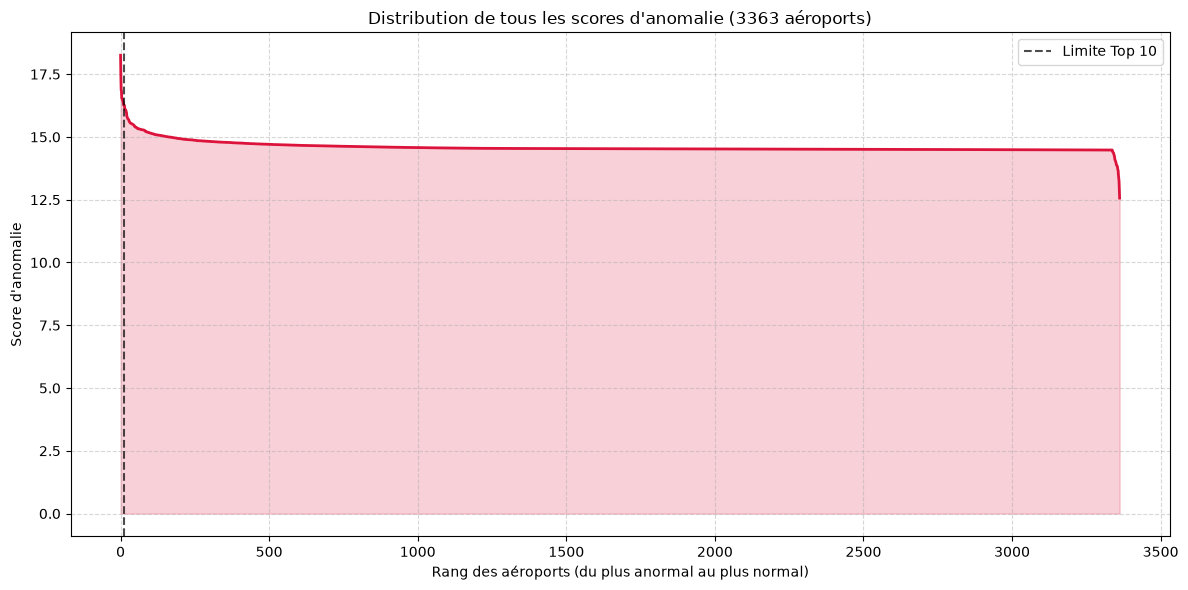

In [22]:
# Tri de tous les scores du plus grand au plus petit
scores_sorted, indices_sorted = th.sort(anomaly_scores, descending=True)

scores_sorted_np = scores_sorted.cpu().numpy()

plt.figure(figsize=(12, 6))

# Courbe / profil de l'ensemble des anomalies
plt.plot(scores_sorted_np, color="crimson", linewidth=2)
plt.fill_between(range(len(scores_sorted_np)), scores_sorted_np, color="crimson", alpha=0.2)

# Ligne indicative pour repérer les cas extrêmes (ex. Top 10)
plt.axvline(x=top_k, color="black", linestyle="--", alpha=0.7, label=f"Limite Top {top_k}")

plt.xlabel("Rang des aéroports (du plus anormal au plus normal)")
plt.ylabel("Score d'anomalie")
plt.title(f"Distribution de tous les scores d'anomalie ({len(scores_sorted_np)} aéroports)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
#Visuellement en utilisant la méthode du coude, on peut enlever tout ce qui a un score > 15 pour un alpha = 0.5
